# Humpback Whale Identification — Classification Baseline

**Course**: Machine Learning for Computer Vision (91266)  
**Task**: [Kaggle Whale Identification Playground](https://www.kaggle.com/competitions/whale-categorization-playground)  
**Authors**: Kristoffer Osen & Sebastian Munthe

## Overview

This notebook implements an improved image classification baseline for humpback whale
identification from fluke photographs. The task is extremely challenging:
- ~4000+ whale identities, most with only 1–5 training images
- A large "new_whale" class representing unidentified individuals
- Fine-grained visual differences (trailing-edge notches, pigmentation patterns)

We systematically address the overfitting problem observed in naive approaches through:
1. **Appropriate augmentation** (conservative, preserving identity cues)
2. **Better backbone** (EfficientNet-B5 at 456px for fine-grained detail)
3. **Freeze/unfreeze training** (preserve pretrained features, then fine-tune)
4. **Focal Loss** (handles extreme class imbalance better than cross-entropy)

All hyperparameters are controlled via a single configuration object, experiments
are indexed and checkpointed automatically, and training can resume from any point.


## Setup & Imports

In [1]:
import sys
import os
import torch
import json

# Ensure our project modules are importable
sys.path.insert(0, os.path.dirname(os.path.abspath("__file__")))

from config import ExperimentConfig
from experiment import ExperimentManager
from dataset import prepare_data, build_dataloaders
from models import WhaleClassifier
from losses import build_loss
from training import train
from visualization import plot_training_history

# Device setup
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using Apple MPS")
else:
    device = torch.device("cpu")
    print("WARNING: No GPU detected. Training will be very slow.")

print(f"PyTorch: {torch.__version__}")
print(f"Device: {device}")


/root/ML4CV/models.py:65: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd(cast_inputs=torch.float32)


GPU: NVIDIA RTX PRO 4000 Blackwell
VRAM: 25.2 GB
PyTorch: 2.10.0+cu130
Device: cuda


## Experiment Configuration

All hyperparameters live in a single `ExperimentConfig` dataclass.  
To run a new experiment, create a new config — previous results are preserved automatically.

### Key design decisions:
- **EfficientNet-B5 at 456×456**: native resolution for this model, captures fine fluke details
- **Batch size 8 × 4 accumulation = 32 effective**: fits in 8GB VRAM with AMP
- **Frozen BN**: pretrained batch norm statistics are more reliable than those from micro-batches
- **Focal Loss (γ=2.0)**: down-weights easy examples, focuses on hard/rare classes
- **3 epochs frozen backbone**: lets the new head learn sensible weights before fine-tuning begins


In [2]:
config = ExperimentConfig(
    # ── Metadata ─────────────────────────────────────────────────
    experiment_name="baseline_effnetb5_focal",
    description="EfficientNet-B5 with Focal Loss, freeze 3 epochs, 456px",

    # ── Paths ────────────────────────────────────────────────────
    data_dir="data",               # Contains train.csv and train/ folder
    experiments_root="experiments",

    # ── Model ────────────────────────────────────────────────────
    backbone="efficientnet_b5",
    image_size=(456, 456),
    embedding_dim=512,

    # ── Freeze strategy ──────────────────────────────────────────
    freeze_backbone_epochs=3,
    freeze_bn=True,

    # ── Training ─────────────────────────────────────────────────
    epochs=35,
    batch_size=16,
    accumulation_steps=2,
    use_amp=True,

    # ── Optimizer ────────────────────────────────────────────────
    lr_head=1e-3,
    lr_backbone=1e-4,
    weight_decay=1e-4,

    # ── Loss ─────────────────────────────────────────────────────
    loss_type="focal",
    focal_gamma=2.0,
    #label_smoothing=0.05,
    use_class_weights=True,

    # ── Scheduler ────────────────────────────────────────────────
    scheduler="cosine",
    warmup_epochs=1,

    # ── Early stopping ───────────────────────────────────────────
    early_stopping_patience=6,
    early_stopping_metric="known_recall@1",

    # ── Ensure replicability ──────────────────────────────────────
    seed=42,
)

print("Experiment config:")
print(config.summary())


Experiment config:
efficientnet_b5 | 456px | focal(γ=2.0) | lr=0.0001/0.001 | freeze=3ep | bs=16×2


## Data Preparation

In [3]:
data = prepare_data(config)

print(f"\nClass mapping: {data['num_classes']} known whale identities")
print(f"ID → Index examples: {dict(list(data['id_to_idx'].items())[:5])} ...")

Split (seed=42): train=7452 (4250 cls), val=1217 (405 new_whale), test=1181 (405 new_whale)

Class mapping: 4250 known whale identities
ID → Index examples: {'w_0013924': 0, 'w_001ebbc': 1, 'w_002222a': 2, 'w_002b682': 3, 'w_002dc11': 4} ...


## Train

The training procedure has two phases:

**Phase 1 — Frozen backbone** (epochs 0–2):
Only the embedding layer and classifier head are trained. This lets the new
head learn sensible weights using stable pretrained features, preventing the
backbone from being corrupted by random gradients from the untrained head.

**Phase 2 — Full fine-tuning** (epochs 3+):
The backbone is unfrozen with a 10× lower learning rate than the head.
BatchNorm layers remain in eval mode throughout (their ImageNet statistics
are more reliable than statistics from our micro-batches).

Training uses:
- **AMP** (Automatic Mixed Precision) for ~50% memory reduction
- **Gradient accumulation** (4 steps) for effective batch size of 32
- **Cosine annealing** with linear warmup
- **Gradient clipping** at norm 1.0


In [4]:
TRAINING_ENABLED = True
EXPERIMENT_ID = "20260526_171819_baseline_effnetb5_focal_d1f9c83d"

if TRAINING_ENABLED:
    # To resume a previous run, set resume_from to its experiment ID:
    manager = train(config, data, device, resume_from=EXPERIMENT_ID)
    # To start fresh:
    #manager = train(config, data, device)
else:
    print("Skipping training")
    config = ExperimentConfig.load("experiments/" + EXPERIMENT_ID + "/config.json")
    manager = ExperimentManager(config, EXPERIMENT_ID)
    

[18:32:09] Resumed experiment: 20260526_171819_baseline_effnetb5_focal_d1f9c83d
[18:32:09] Config: efficientnet_b5 | 456px | focal(γ=2.0) | lr=0.0001/0.001 | freeze=3ep | bs=16×2
[18:32:09] Resume mode active for experiment: 20260526_171819_baseline_effnetb5_focal_d1f9c83d
[18:32:10] Resume checkpoint indicates UNFROZEN optimizer state.

Model: efficientnet_b5 (head=linear)
  Input size:     (456, 456)
  Embedding dim:  512
  Total params:     31,571,146
  Backbone:         28,340,784
  Head:              3,230,362
  Trainable:        31,571,146 (100.0%)
  Frozen:                    0 (0.0%)

[18:32:10] Loss: focal | Head: linear
[18:32:10] Loading checkpoint: experiments/20260526_171819_baseline_effnetb5_focal_d1f9c83d/checkpoints/latest.pth
[18:32:10] Resuming from epoch 25
[18:32:10] 
Starting training: 35 epochs, effective batch size = 32


  Train Ep 25:   0%|          | 0/465 [00:00<?, ?it/s]

Extracting Classifier Preds:   0%|          | 0/39 [00:00<?, ?it/s]

  Val   Ep 25:   0%|          | 0/39 [00:00<?, ?it/s]

[18:34:40] Epoch  25/35 [UNFROZEN] | Train Loss: 1.0372  Acc: 99.9% | Val known_recall@1: 55.0%  LR: 1.55e-06 | Time: 2.5m
[18:35:01]   ✓ New best model saved (epoch 25, known_recall@1=0.5505)


...

[18:52:43] Epoch  32/35 [UNFROZEN] | Train Loss: 1.0553  Acc: 99.8% | Val known_recall@1: 51.1%  LR: 3.24e-05 | Time: 1.8m


  Train Ep 33:   0%|          | 0/465 [00:00<?, ?it/s]

Extracting Classifier Preds:   0%|          | 0/39 [00:00<?, ?it/s]

  Val   Ep 33:   0%|          | 0/39 [00:00<?, ?it/s]

[18:55:22] Epoch  33/35 [UNFROZEN] | Train Loss: 1.0626  Acc: 99.9% | Val known_recall@1: 52.1%  LR: 3.95e-05 | Time: 2.3m
[18:55:43] 
Early stopping triggered (no improvement for 6 epochs)
[18:55:43] 
Training complete in 23.5 minutes.
[18:55:43] Best epoch: 27 (known_recall@1=0.5530)


## Training Analysis

/root/ML4CV/visualization.py:75: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="upper left")


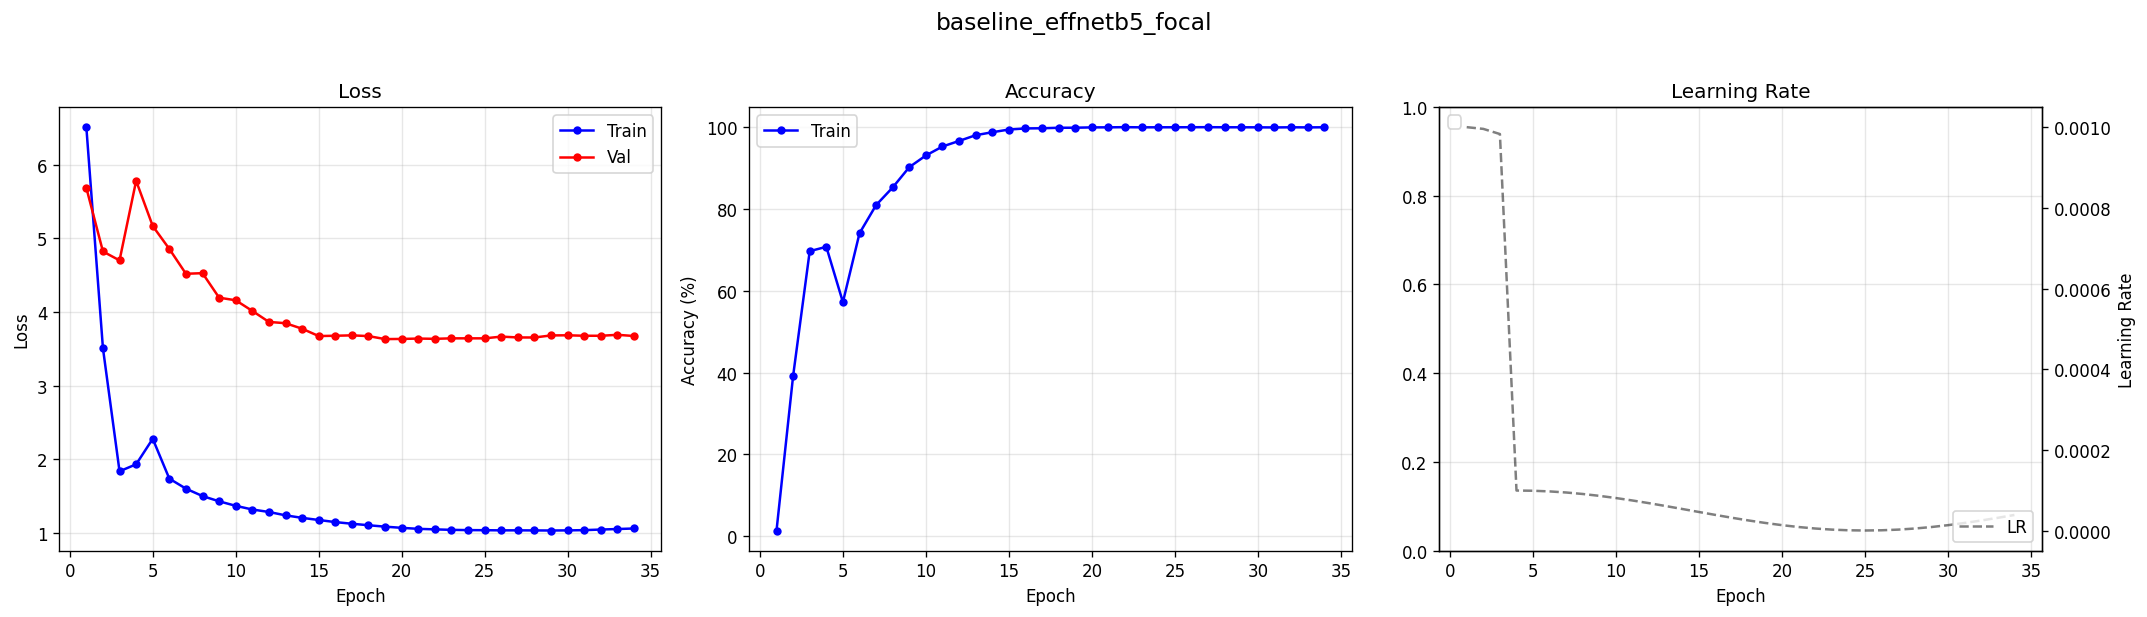

In [5]:
# Load metrics from the completed experiment
metrics_path = manager.root / "metrics.json"
with open(metrics_path, "r") as f:
    metrics = json.load(f)

plot_training_history(metrics, title=config.experiment_name)


In [6]:
print("\nFinal metrics (last epoch):")
for key in ["train_loss", "val_loss", "val_known_acc",
            "val_mean_known_conf"]:
    if key in metrics:
        val = metrics[key][-1]
        if "acc" in key or "detection" in key:
            print(f"  {key:<30s}: {val * 100:.2f}%")
        else:
            print(f"  {key:<30s}: {val:.4f}")



Final metrics (last epoch):
  train_loss                    : 1.0626
  val_loss                      : 3.6751


## Evaluate Best Model

Load the best checkpoint and run detailed evaluation.


In [7]:
# Load best model

best_model = WhaleClassifier(
    backbone_name=config.backbone,
    num_classes=data["num_classes"],
    embedding_dim=config.embedding_dim,
    pretrained=False,  # Loading trained weights instead
).to(device)

manager.load_checkpoint(best_model, checkpoint="best")

# Run evaluation
criterion = build_loss(config, data["class_counts"], device)
val_metrics = evaluate(best_model, val_loader, criterion, config, device, epoch=0)

print("\nBest model validation metrics:")
for k, v in val_metrics.items():
    if isinstance(v, float):
        if "acc" in k or "detection" in k:
            print(f"  {k:<30s}: {v * 100:.2f}%")
        else:
            print(f"  {k:<30s}: {v:.4f}")
    else:
        print(f"  {k:<30s}: {v}")


[19:02:57] Loading checkpoint: experiments/20260526_171819_baseline_effnetb5_focal_d1f9c83d/checkpoints/best.pth
[19:02:58] Resuming from epoch 28


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7f9964606840>
Traceback (most recent call last):
  File "/venv/main/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/venv/main/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1671, in _shutdown_workers
    w.join(timeout=_utils.MP_STATUS_CHECK_INTERVAL)
  File "/venv/main/lib/python3.12/multiprocessing/process.py", line 149, in join
    res = self._popen.wait(timeout)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/venv/main/lib/python3.12/multiprocessing/popen_fork.py", line 40, in wait
    if not wait([self.sentinel], timeout):
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/venv/main/lib/python3.12/multiprocessing/connection.py", line 1136, in wait
    ready = selector.select(timeout)
            ^^^^^^^^^^^^^^^^^^^^^^^^
  File "/venv/main/lib/python3.12/selectors.py", line 415, in select
    fd_event_list = self._sel

NameError: name 'evaluate' is not defined

## Embedding Quality

In [ ]:
# ── Load the best baseline model ──────────────────────────────────
from pathlib import Path

from dataset import build_retrieval_eval_loaders
from dataset import get_eval_config_and_data
from models import build_model

eval_config, data = get_eval_config_and_data()

BASELINE_CHECKPOINT = "experiments/" + EXPERIMENT_ID + "/checkpoints/best.pth"

try:
    ckpt_path = Path(BASELINE_CHECKPOINT)
    baseline_config_path = ckpt_path.parent.parent / "config.json"
    baseline_train_config = ExperimentConfig.load(str(baseline_config_path))

    baseline_model = build_model(
        baseline_train_config,
        num_classes=data["num_classes"],
        device=device,
    )

    state = torch.load(BASELINE_CHECKPOINT, map_location=device, weights_only=False)
    baseline_model.load_state_dict(state["model_state_dict"])

    print("Baseline model loaded successfully.")
    print(f"Using baseline training config: {baseline_config_path}")

    # Retrieval evaluation with shared protocol (comparable across models)
    train_loader, val_loader = build_retrieval_eval_loaders(eval_config, data)

    print("\nBaseline retrieval performance:")
    baseline_retrieval = evaluate_retrieval(
        baseline_model, train_loader, val_loader,
        eval_config, device,
    )
except FileNotFoundError:
    print(f"Baseline checkpoint not found at: {BASELINE_CHECKPOINT}")
    print("Train the baseline first using notebook 01, then update the path above.")
    baseline_model = None

Split (seed=42): train=7136 (4250 cls), val=1102 (405 new_whale), test=1612 (405 new_whale)


Baseline model loaded successfully.
Using baseline training config: experiments/20260525_195229_baseline_effnetb5_focal_6879e346/config.json

Baseline retrieval performance:


  Extracting embeddings:   0%|          | 0/298 [00:00<?, ?it/s]

  Gallery: 7136 embeddings, 4250 identities


  Extracting embeddings:   0%|          | 0/46 [00:00<?, ?it/s]

  Recall@1: 56.96%  Recall@5: 69.87%  


### t-SNE Visualization of Baseline Embeddings

t-SNE projects the high-dimensional embeddings to 2D for visualization.
If the baseline embedding is well-structured, we should see clusters — but
as the course predicts (slide 11), cross-entropy embeddings tend to form
elongated rays rather than compact blobs.


  Extracting embeddings:   0%|          | 0/46 [00:00<?, ?it/s]

  Extracting embeddings:   0%|          | 0/594 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x79a799d0a840>
Traceback (most recent call last):
  File "/venv/main/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/venv/main/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/venv/main/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x79a799d0a840>
Traceback (most recent call last):
  File "/venv/main/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/venv/main/lib/python3.12/site-packages/torch/utils/data/dataloader.py", l

t-SNE: 216 points, 10 classes (min 5/class)


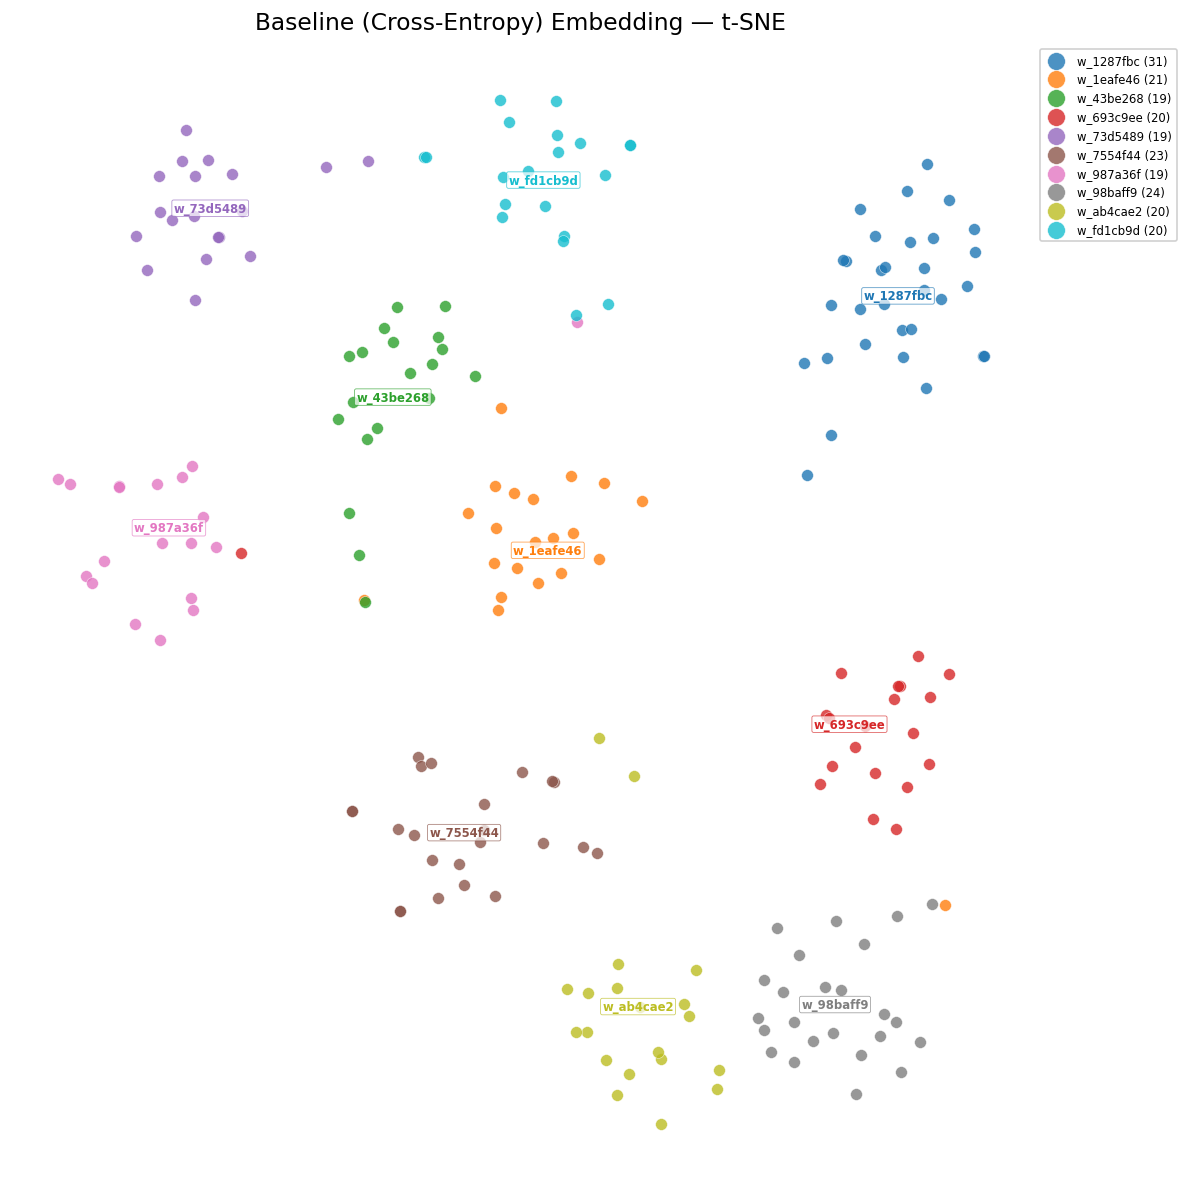

  Perplexity used: 27 | KL divergence: 0.42


In [ ]:
# ── Usage ────────────────────────────────────────────────────────────────
# Combine train + val loaders to get enough points per class for visible clusters.
# This is purely for visualization — evaluation metrics stay on val only.
from visualization import plot_embedding_tsne

if baseline_model is not None:
    train_loader_viz, val_loader_viz = build_dataloaders(eval_config, data)
    plot_embedding_tsne(
        baseline_model, val_loader_viz, data, device,
        title="Baseline (Cross-Entropy) Embedding — t-SNE",
        top_k_classes=10,
        min_samples_per_class=5,
        combine_loaders=[train_loader_viz],
    )